In [3]:
# Cell 1: Imports

import os
import sys

import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Add IntegrAO to path
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from integrao.integrater import integrao_integrater, integrao_predictor

print("Torch CUDA available:", torch.cuda.is_available())


Torch CUDA available: False


In [2]:
# Cell 2: Hyperparameters & result directory

neighbor_size = 20
embedding_dims = 64
fusing_iteration = 30
normalization_factor = 1.0
alighment_epochs = 1000
beta = 1.0
mu = 0.5

dataset_name = "supervised_integration_feature_importance"
cluster_number = 4

result_dir = os.path.join(module_path, "results", dataset_name)
os.makedirs(result_dir, exist_ok=True)

result_dir


'/Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance'

In [4]:
# Cell 3: Load pickled TCGA-BRCA omics

data_dir = "./../data/TCGA-BRCA/"
omics = ["mRNA", "DNAm", "RPPA"]

data = {}
for omic in omics:
    with open(f"{data_dir}{omic}.pkl", "rb") as f:
        data[omic] = pickle.load(f)

list(data.keys()), list(data["mRNA"].keys())


(['mRNA', 'DNAm', 'RPPA'], ['expr', 'meta'])

In [5]:
# Cell 4: Build intersection and keep full (union) copies

dna = data["DNAm"]["expr"]
rna = data["mRNA"]["expr"]
rppa = data["RPPA"]["expr"]

# full (union) copies for incomplete-omics inference later
dna_full = dna.copy()
rna_full = rna.copy()
rppa_full = rppa.copy()

# intersection: patients that have all 3 omics
all_samples = dna.index.intersection(rna.index).intersection(rppa.index)

dna = dna.loc[all_samples]
rna = rna.loc[all_samples]
rppa = rppa.loc[all_samples]

dna.shape, rna.shape, rppa.shape


((401, 100000), (401, 29995), (401, 464))

In [6]:
# Cell 5: Encode PAM50 labels for intersection samples

labels_raw = data["DNAm"]["meta"].loc[all_samples, "paper_BRCA_Subtype_PAM50"]

label_encoder = LabelEncoder()
labels_numeric = label_encoder.fit_transform(labels_raw) + 1  # map to 1..4

pam50_classes = list(label_encoder.classes_)
print("PAM50 class mapping (1-based):")
for i, c in enumerate(pam50_classes, start=1):
    print(f"{c}: {i}")

truelabel = pd.DataFrame({
    "subjects": labels_raw.index,
    "cluster.id": labels_numeric
})

truelabel.head(), truelabel["cluster.id"].value_counts()


PAM50 class mapping (1-based):
Basal: 1
Her2: 2
LumA: 3
LumB: 4


(       subjects  cluster.id
 0  TCGA-E9-A228           4
 1  TCGA-HN-A2NL           1
 2  TCGA-OL-A5D7           1
 3  TCGA-A2-A3KC           3
 4  TCGA-A2-A0YI           3,
 cluster.id
 3    230
 4     82
 1     61
 2     28
 Name: count, dtype: int64)

In [7]:
# Cell 6: Variance-based feature selection + full matrices

views_expr = {
    "dna": dna,
    "rna": rna,
    "rppa": rppa,
}

data_fs = {}
feature_lists = {}

n_keep = 2000

for view_name, expr_df in views_expr.items():
    if view_name == "rppa":
        # RPPA is low-dimensional already
        expr_sel = expr_df.copy()
        feature_lists[view_name] = expr_sel.columns
    else:
        feature_var = expr_df.var(axis=0, skipna=True)
        top_features = feature_var.sort_values(ascending=False).head(n_keep).index
        expr_sel = expr_df.loc[:, top_features]
        feature_lists[view_name] = top_features

    data_fs[view_name] = expr_sel

# Training (intersection) views
methyl  = data_fs["rna"]
expr    = data_fs["dna"]
protein = data_fs["rppa"]

print("Intersection feature-shapes:")
print("methyl:", methyl.shape, "expr:", expr.shape, "protein:", protein.shape)

# Full (union) feature-selected matrices using same feature sets
dna_full_fs = dna_full.loc[:, feature_lists["dna"]]
rna_full_fs = rna_full.loc[:, feature_lists["rna"]]
rppa_full_fs = rppa_full.loc[:, feature_lists["rppa"]]

methyl_full  = rna_full_fs
expr_full    = dna_full_fs
protein_full = rppa_full_fs

print("Union feature-shapes:")
print("methyl_full:", methyl_full.shape, 
      "expr_full:", expr_full.shape, 
      "protein_full:", protein_full.shape)


Intersection feature-shapes:
methyl: (401, 2000) expr: (401, 2000) protein: (401, 464)
Union feature-shapes:
methyl_full: (500, 2000) expr_full: (500, 2000) protein_full: (500, 464)


In [8]:
# Cell 7: Metric helper

def get_metrics(preds, preds_index, X_test, y_test, return_preds=False):
    """
    preds: numpy array of predictions for all patients in the UNION dataset
    preds_index: index (or index-like) corresponding to preds (union patient IDs)
    X_test: index of test patients (intersection only)
    y_test: ground-truth labels for test patients (1..4)
    """
    # Handle case where preds_index might be a dict (e.g. sample -> idx)
    if isinstance(preds_index, dict):
        index_for_df = list(preds_index.keys())
    else:
        index_for_df = preds_index

    pred_df = pd.DataFrame(preds, index=index_for_df)

    # extract only test patients
    pred_df_test = pred_df.loc[X_test]

    # Integrao predictions are 0-based class indices; convert back to 1..4
    pred_labels = pred_df_test.iloc[:, 0] + 1

    f1_micro = f1_score(y_test, pred_labels, average="micro")
    f1_weighted = f1_score(y_test, pred_labels, average="weighted")
    acc = accuracy_score(y_test, pred_labels)

    if return_preds:
        return f1_micro, f1_weighted, acc, pred_labels
    else:
        return f1_micro, f1_weighted, acc


In [9]:
# Cell 8: 5-fold Stratified CV with union-based inference

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

all_results = []
conf_matrices = []

common_patient = methyl.index
y_all = truelabel.set_index("subjects").loc[common_patient, "cluster.id"].values

fold_id = 1

for train_idx, test_idx in skf.split(common_patient, y_all):
    print(f"\n========== Fold {fold_id} / {K} ==========")

    # Split intersection patients
    X_train = common_patient[train_idx]
    X_test  = common_patient[test_idx]
    y_train = y_all[train_idx]
    y_test  = y_all[test_idx]

    # Reference (train) views
    methyl_ref  = methyl.loc[X_train]
    expr_ref    = expr.loc[X_train]
    protein_ref = protein.loc[X_train]

    # ---- STEP 1: Unsupervised integration (intersection train only) ----
    integrater = integrao_integrater(
        [methyl_ref, expr_ref, protein_ref],
        dataset_name,
        modalities_name_list=["methyl", "expr", "protein"],
        neighbor_size=neighbor_size,
        embedding_dims=embedding_dims,
        fusing_iteration=fusing_iteration,
        normalization_factor=normalization_factor,
        alighment_epochs=alighment_epochs,
        beta=beta,
        mu=mu,
    )

    integrater.network_diffusion()
    embeds_final, S_final, model = integrater.unsupervised_alignment()

    # ---- STEP 2: Supervised fine-tuning on training patients ----
    # Prepare labels (0-based for IntegrAO)
    truelabel_sub = truelabel.set_index("subjects").loc[X_train].copy()
    truelabel_sub["cluster.id"] -= 1

    embeds_final, S_final, model, preds_sup = integrater.classification_finetuning(
        truelabel_sub,
        result_dir,
        finetune_epochs=800,
    )

    # Save per-fold model
    model_path = os.path.join(result_dir, f"model_fold{fold_id}.pth")
    torch.save(model.state_dict(), model_path)

    # ---- STEP 3: Build predictor on UNION datasets (incomplete omics allowed) ----
    predictor = integrao_predictor(
        [methyl_full, expr_full, protein_full],
        dataset_name,
        modalities_name_list=["methyl", "expr", "protein"],
        neighbor_size=neighbor_size,
        embedding_dims=embedding_dims,
        fusing_iteration=fusing_iteration,
        normalization_factor=normalization_factor,
        alighment_epochs=alighment_epochs,
        beta=beta,
        mu=mu,
        num_classes=cluster_number,
    )

    predictor.network_diffusion()

    preds = predictor.inference_supervised(
        model_path,
        new_datasets=[methyl_full, expr_full, protein_full],
        modalities_names=["methyl", "expr", "protein"],
    )

    # sample order from predictor
    preds_index = predictor.dict_sampleToIndexs  # works with get_metrics

    # ---- STEP 4: Evaluate this fold ----
    f1_micro, f1_weighted, acc, pred_labels = get_metrics(
        preds, preds_index, X_test, y_test, return_preds=True
    )

    print(
        f"Fold {fold_id} results: "
        f"F1_micro={f1_micro:.3f}  "
        f"F1_weighted={f1_weighted:.3f}  "
        f"Acc={acc:.3f}"
    )

    all_results.append((f1_micro, f1_weighted, acc))

    # confusion matrix for this fold
    cm = confusion_matrix(y_test, pred_labels, labels=[1, 2, 3, 4])
    conf_matrices.append(cm)

    fold_id += 1

# convert to array
all_results = np.array(all_results)



========== Fold 1 / 5 ==========
Start indexing input expression matrices!
Common sample between view0 and view1: 320
Common sample between view0 and view2: 320
Common sample between view1 and view2: 320
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 3.7977793216705322s
Starting unsupervised exmbedding extraction!
Dataset 0: (320, 2000)
Dataset 1: (320, 2000)
Dataset 2: (320, 464)
epoch 0: loss 24.012418746948242, align_loss:0.702839
epoch 100: loss 19.91172981262207, align_loss:0.240819
epoch 200: loss 0.9377983808517456, align_loss:0.131769
epoch 300: loss 0.9366264939308167, align_loss:0.131011
epoch 400: loss 0.9352672100067139, align_loss:0.130258
epoch 500: loss 0.9337577819824219, align_loss:0.129443
epoch 600: loss 0.932088315486908, align_loss:0.128657
epoch 700: loss 0.9303207397460938, align_loss:0.127981
epoch 800: loss 0.9284437894821167, align_loss:0.127232
epoch 900: loss 0.9262439012527466, align_loss:0.126332
Manifold alignment ends! Times: 32.7807

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 0: loss 2.5235755443573, kl_loss:0.828389, align_loss:0.123081, clf_loss:1.572105
epoch 100: loss 0.8202797174453735, kl_loss:0.725645, align_loss:0.093470, clf_loss:0.001165
epoch 200: loss 0.7990691065788269, kl_loss:0.709849, align_loss:0.088509, clf_loss:0.000711
epoch 300: loss 0.7965571880340576, kl_loss:0.708004, align_loss:0.087876, clf_loss:0.000677
epoch 400: loss 0.7936084270477295, kl_loss:0.705848, align_loss:0.087119, clf_loss:0.000641
epoch 500: loss 0.7902917861938477, kl_loss:0.703448, align_loss:0.086240, clf_loss:0.000604
epoch 600: loss 0.7867004871368408, kl_loss:0.700894, align_loss:0.085246, clf_loss:0.000560
epoch 700: loss 0.7829914689064026, kl_loss:0.698282, align_loss:0.084186, clf_loss:0.000523
Manifold alignment ends! Times: 29.795078992843628s
Start indexing input expression matrices!
Common sample between view0 and view1: 415
Common sample between view0 and view2: 414
Common sample between view1 and view2: 414
Neighbor size: 20
Start applying diffu

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

Fold 1 results: F1_micro=0.877  F1_weighted=0.878  Acc=0.877

========== Fold 2 / 5 ==========
Start indexing input expression matrices!
Common sample between view0 and view1: 321
Common sample between view0 and view2: 321
Common sample between view1 and view2: 321
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 2.414170980453491s
Starting unsupervised exmbedding extraction!
Dataset 0: (321, 2000)
Dataset 1: (321, 2000)
Dataset 2: (321, 464)
epoch 0: loss 24.225788116455078, align_loss:0.746525
epoch 100: loss 20.037357330322266, align_loss:0.225907
epoch 200: loss 0.9661911725997925, align_loss:0.127315
epoch 300: loss 0.9653371572494507, align_loss:0.126787
epoch 400: loss 0.9643412828445435, align_loss:0.126267
epoch 500: loss 0.9632198214530945, align_loss:0.125750
epoch 600: loss 0.9619606733322144, align_loss:0.125210
epoch 700: loss 0.9605940580368042, align_loss:0.124605
epoch 800: loss 0.9590858221054077, align_loss:0.124164
epoch 900: loss 0.957392334938049

...

Fold 4 results: F1_micro=0.863  F1_weighted=0.863  Acc=0.863

========== Fold 5 / 5 ==========
Start indexing input expression matrices!
Common sample between view0 and view1: 321
Common sample between view0 and view2: 321
Common sample between view1 and view2: 321
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 2.482448101043701s
Starting unsupervised exmbedding extraction!
Dataset 0: (321, 2000)
Dataset 1: (321, 2000)
Dataset 2: (321, 464)
epoch 0: loss 24.16521453857422, align_loss:0.726386
epoch 100: loss 19.973796844482422, align_loss:0.216156
epoch 200: loss 0.9465348720550537, align_loss:0.123542
epoch 300: loss 0.9455769658088684, align_loss:0.122930
epoch 400: loss 0.9444491863250732, align_loss:0.122276
epoch 500: loss 0.9431899189949036, align_loss:0.121529
epoch 600: loss 0.9418033361434937, align_loss:0.120827
epoch 700: loss 0.9402754902839661, align_loss:0.120040
epoch 800: loss 0.9386181831359863, align_loss:0.119263
epoch 900: loss 0.9368187189102173

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 0: loss 2.6213364601135254, kl_loss:0.839549, align_loss:0.118439, clf_loss:1.663348
epoch 100: loss 0.8247764706611633, kl_loss:0.740852, align_loss:0.082545, clf_loss:0.001380
epoch 200: loss 0.8016738891601562, kl_loss:0.721895, align_loss:0.078535, clf_loss:0.001244
epoch 300: loss 0.7989945411682129, kl_loss:0.719700, align_loss:0.078066, clf_loss:0.001228
epoch 400: loss 0.7958488464355469, kl_loss:0.717241, align_loss:0.077409, clf_loss:0.001199
epoch 500: loss 0.7922876477241516, kl_loss:0.714461, align_loss:0.076669, clf_loss:0.001157
epoch 600: loss 0.7884185910224915, kl_loss:0.711456, align_loss:0.075862, clf_loss:0.001101
epoch 700: loss 0.784305989742279, kl_loss:0.708310, align_loss:0.074936, clf_loss:0.001060
Manifold alignment ends! Times: 27.106751203536987s
Start indexing input expression matrices!
Common sample between view0 and view1: 415
Common sample between view0 and view2: 414
Common sample between view1 and view2: 414
Neighbor size: 20
Start applying dif

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

Fold 5 results: F1_micro=0.838  F1_weighted=0.832  Acc=0.838


In [10]:
# Cell 9: Summary metrics

f1_micro_mean    = all_results[:, 0].mean()
f1_micro_std     = all_results[:, 0].std()

f1_weighted_mean = all_results[:, 1].mean()
f1_weighted_std  = all_results[:, 1].std()

acc_mean         = all_results[:, 2].mean()
acc_std          = all_results[:, 2].std()

print("\n===== Final Cross-Validation Results =====")
print(f"F1_micro:    mean = {f1_micro_mean:.4f}, std = {f1_micro_std:.4f}")
print(f"F1_weighted: mean = {f1_weighted_mean:.4f}, std = {f1_weighted_std:.4f}")
print(f"Accuracy:    mean = {acc_mean:.4f}, std = {acc_std:.4f}")



===== Final Cross-Validation Results =====
F1_micro:    mean = 0.8453, std = 0.0222
F1_weighted: mean = 0.8444, std = 0.0222
Accuracy:    mean = 0.8453, std = 0.0222


/var/folders/tt/c0ph4yks47qf6jml4nwy1yb00000gn/T/ipykernel_67553/4219046381.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_results, labels=metric_names)


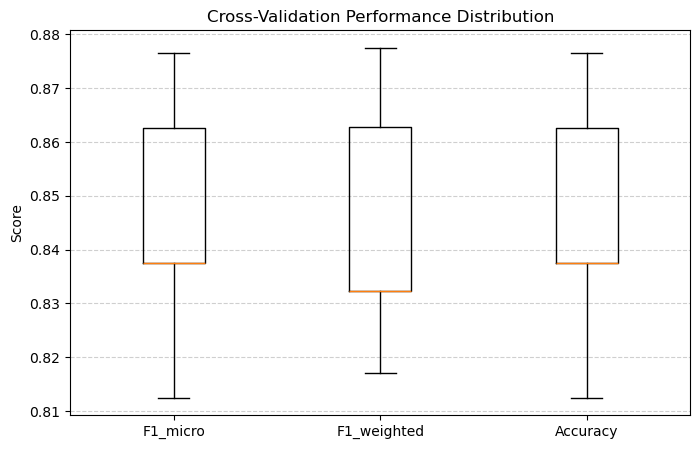

In [11]:
# Cell 10: Boxplot of CV metrics

metric_names = ["F1_micro", "F1_weighted", "Accuracy"]

plt.figure(figsize=(8, 5))
plt.boxplot(all_results, labels=metric_names)
plt.title("Cross-Validation Performance Distribution")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


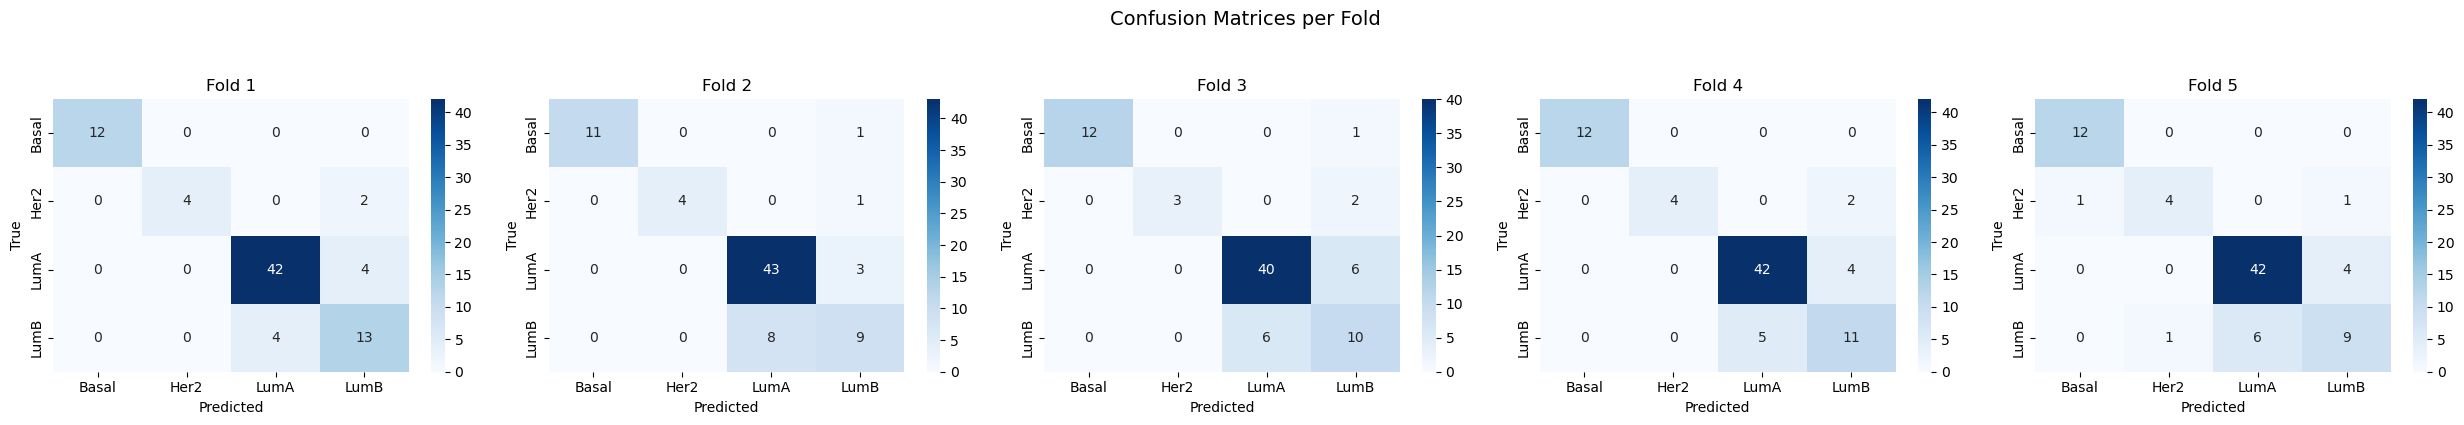

In [12]:
# Cell 11: Confusion matrices per fold

num_folds = len(conf_matrices)
fig, axes = plt.subplots(1, num_folds, figsize=(5 * num_folds, 4), squeeze=False)

for i, cm in enumerate(conf_matrices):
    ax = axes[0, i]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=pam50_classes,
        yticklabels=pam50_classes,
        ax=ax,
    )
    ax.set_title(f"Fold {i+1}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices per Fold", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


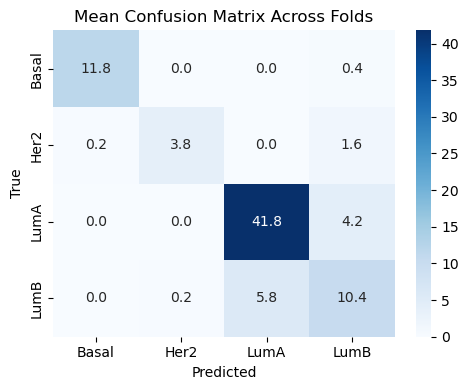

In [13]:
# Cell 12: Mean confusion matrix

mean_conf = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(5, 4))
sns.heatmap(
    mean_conf,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=pam50_classes,
    yticklabels=pam50_classes,
)
plt.title("Mean Confusion Matrix Across Folds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.manifold import UMAP

# Extract embeddings from predictor (after network_diffusion)
# Predictor stores the final aligned embeddings in predictor.embeds_final
# But some versions don't expose it; this is safer:

embeddings = predictor.embeds  # if available
patient_ids = list(predictor.dict_sampleToIndexs.keys())

emb_df = pd.DataFrame(embeddings, index=patient_ids)

# Reduce to 2D using UMAP
umap = UMAP(n_components=2, random_state=42)
coords = umap.fit_transform(emb_df)

plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], s=10, alpha=0.8)
plt.title("UMAP of IntegrAO Embeddings (Union Patients)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


ImportError: cannot import name 'UMAP' from 'sklearn.manifold' (/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/manifold/__init__.py)

In [16]:
from sklearn.manifold import TSNE

coords = TSNE(n_components=2, learning_rate='auto').fit_transform(emb_df)

plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], c=preds.flatten()+1, cmap='viridis', s=8)
plt.title("t-SNE of IntegrAO Embeddings Colored by Predicted PAM50")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.colorbar()
plt.show()


NameError: name 'emb_df' is not defined

In [17]:
# Cell: Interpretability — train model on ALL intersection patients

# Use full intersection dataset
methyl_int  = methyl        # (401, 2000)
expr_int    = expr          # (401, 2000)
protein_int = protein       # (401, 464)

# Prepare labels (0-based for integrater)
labels_int = truelabel.set_index("subjects")["cluster.id"] - 1
labels_int = labels_int.loc[methyl_int.index]  # aligned order

# 1) Unsupervised integration
integrater_int = integrao_integrater(
    [methyl_int, expr_int, protein_int],
    dataset_name,
    modalities_name_list=["methyl","expr","protein"],
    neighbor_size=neighbor_size,
    embedding_dims=embedding_dims,
    fusing_iteration=fusing_iteration,
    normalization_factor=normalization_factor,
    alighment_epochs=alighment_epochs,
    beta=beta,
    mu=mu,
)

integrater_int.network_diffusion()
embeds_int, S_int, model_int = integrater_int.unsupervised_alignment()

# 2) Supervised fine-tuning on ALL labels
labels_int_df = pd.DataFrame({"cluster.id": labels_int.values}, index=labels_int.index)

embeds_int, S_int, model_int, preds_int = integrater_int.classification_finetuning(
    labels_int_df,
    result_dir,
    finetune_epochs=800,
)

# Save interpretability model
model_path_int = os.path.join(result_dir, "model_for_interpretation.pth")
torch.save(model_int.state_dict(), model_path_int)


Start indexing input expression matrices!
Common sample between view0 and view1: 401
Common sample between view0 and view2: 401
Common sample between view1 and view2: 401
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 4.191496133804321s
Starting unsupervised exmbedding extraction!
Dataset 0: (401, 2000)
Dataset 1: (401, 2000)
Dataset 2: (401, 464)
epoch 0: loss 24.86353302001953, align_loss:0.664120
epoch 100: loss 20.531219482421875, align_loss:0.237461
epoch 200: loss 1.086966633796692, align_loss:0.127820
epoch 300: loss 1.08601713180542, align_loss:0.127310
epoch 400: loss 1.0849095582962036, align_loss:0.126729
epoch 500: loss 1.0836964845657349, align_loss:0.126104
epoch 600: loss 1.082390546798706, align_loss:0.125458
epoch 700: loss 1.0809720754623413, align_loss:0.124840
epoch 800: loss 1.079477071762085, align_loss:0.124303
epoch 900: loss 1.0779085159301758, align_loss:0.123690
Manifold alignment ends! Times: 36.11111116409302s
Starting supervised finetin

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 0: loss 2.4836249351501465, kl_loss:1.001057, align_loss:0.118229, clf_loss:1.364340
epoch 100: loss 1.029801845550537, kl_loss:0.929189, align_loss:0.099811, clf_loss:0.000801
epoch 200: loss 0.9961485266685486, kl_loss:0.899146, align_loss:0.096375, clf_loss:0.000628
epoch 300: loss 0.9918683171272278, kl_loss:0.895866, align_loss:0.095389, clf_loss:0.000614
epoch 400: loss 0.9866878390312195, kl_loss:0.891703, align_loss:0.094381, clf_loss:0.000604
epoch 500: loss 0.9804338812828064, kl_loss:0.886744, align_loss:0.093085, clf_loss:0.000605
epoch 600: loss 0.9723920226097107, kl_loss:0.880219, align_loss:0.091528, clf_loss:0.000645
epoch 700: loss 0.9617976546287537, kl_loss:0.871308, align_loss:0.089720, clf_loss:0.000770
Manifold alignment ends! Times: 33.69300127029419s


In [19]:
# Build predictor on the SAME intersection dataset
predictor_int = integrao_predictor(
    [methyl_int, expr_int, protein_int],
    dataset_name,
    modalities_name_list=["methyl","expr","protein"],
    neighbor_size=neighbor_size,
    embedding_dims=embedding_dims,
    fusing_iteration=fusing_iteration,
    normalization_factor=normalization_factor,
    alighment_epochs=alighment_epochs,
    beta=beta,
    mu=mu,
    num_classes=cluster_number,
)

predictor_int.network_diffusion()

# Run integrated gradients to extract feature attributions
df_list = predictor_int.interpret_supervised(
    model_path=model_path_int,
    result_dir=result_dir,
    new_datasets=[methyl_int, expr_int, protein_int],
    modalities_names=["methyl","expr","protein"]
)


Start indexing input expression matrices!
Common sample between view0 and view1: 401
Common sample between view0 and view2: 401
Common sample between view1 and view2: 401
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 4.312758922576904s
IntegrAO(
  (feature): ModuleList(
    (0-1): 2 x GraphSAGE(2000, 64, num_layers=2)
    (2): GraphSAGE(464, 64, num_layers=2)
  )
  (feature_show): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (pred_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)
Loaded pre-trained mode

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

(401, 2000)
Saved feature importances for domain methyl to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/methyl_feat_importance.csv
(401, 2000)
Saved feature importances for domain expr to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/expr_feat_importance.csv
(401, 464)
Saved feature importances for domain protein to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/protein_feat_importance.csv


In [27]:
# Cell: Aggregate feature importances

feature_importances = {}

for name, df in zip(["methyl", "expr", "protein"], df_list):
    mean_scores = df.abs().mean(axis=0)     # average over all patients
    feature_importances[name] = mean_scores.sort_values(ascending=False)

feature_importances_corrected = {
    "mRNA": feature_importances["methyl"],     # genes
    "DNAm": feature_importances["expr"],       # CpG sites
    "RPPA": feature_importances["protein"]     # proteins
}

feature_importances_corrected["mRNA"].head(20)
feature_importances_corrected["DNAm"].head(20)
feature_importances_corrected["RPPA"].head(20)


feat_164    0.000996
feat_187    0.000901
feat_175    0.000664
feat_156    0.000507
feat_294    0.000419
feat_229    0.000398
feat_143    0.000397
feat_78     0.000334
feat_146    0.000334
feat_224    0.000330
feat_219    0.000326
feat_192    0.000324
feat_360    0.000296
feat_163    0.000291
feat_177    0.000284
feat_344    0.000282
feat_16     0.000280
feat_186    0.000276
feat_416    0.000263
feat_290    0.000247
dtype: float64

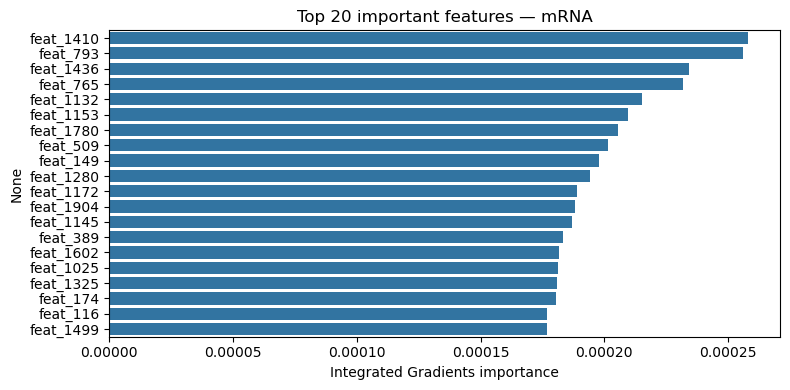

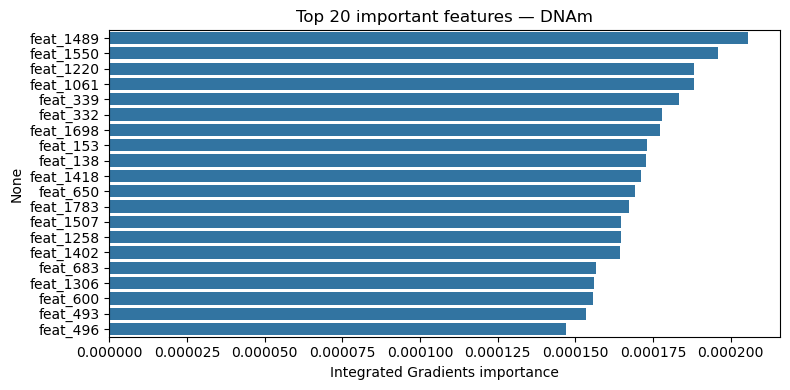

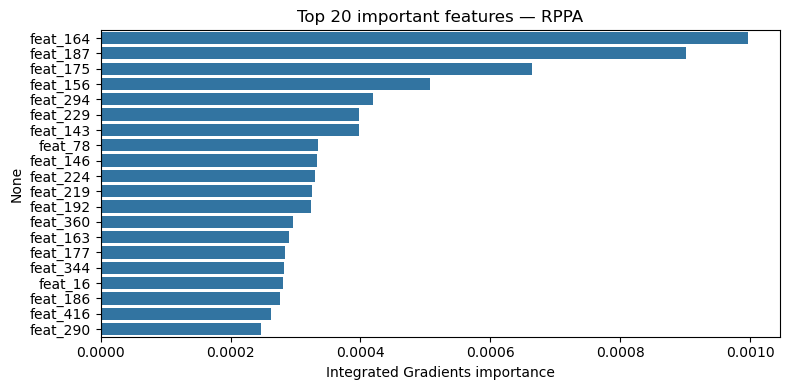

In [28]:
for name in ["mRNA", "DNAm" , "RPPA"]:
    top20 = feature_importances_corrected[name].head(20)
    plt.figure(figsize=(8,4))
    sns.barplot(x=top20.values, y=top20.index, orient='h')
    plt.title(f"Top 20 important features — {name}")
    plt.xlabel("Integrated Gradients importance")
    plt.tight_layout()
    plt.show()


In [22]:
# CLASS-SPECIFIC INTEGRATED GRADIENTS

import torch
from captum.attr import IntegratedGradients

def get_class_specific_ig(predictor, model_path, 
                          new_datasets, modalities_names, 
                          target_class):
    """
    Runs Integrated Gradients for a specific class (0-based PAM50 class ID).
    Returns: list of DataFrames [IG_mRNA, IG_DNAm, IG_RPPA]
    """
    
    # Load model weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = predictor.model
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    # build x_dict of feature matrices
    x_dict = predictor._make_x_dict(new_datasets, modalities_names)
    edge_index_dict = predictor.edge_index_dict
    domain_order = predictor.dict_original_order

    # For each modality run IG separately
    df_list = []

    for domain_idx, domain in enumerate(modalities_names):

        # x_input = features for this domain only (requires grad)
        x_input = torch.tensor(x_dict[domain], dtype=torch.float32, device=device, requires_grad=True)

        # Static (non-updated) features for other views
        static_x = {k: torch.tensor(v, dtype=torch.float32, device=device)
                    for k, v in x_dict.items() if k != domain}

        ig = IntegratedGradients(
            lambda x: model({**static_x, domain: x},
                            edge_index_dict,
                            domain_order)[2][:, target_class]
        )

        attributions = ig.attribute(
            inputs=x_input,
            target=None,
            return_convergence_delta=False
        )

        # Move to pandas
        df = pd.DataFrame(
            attributions.detach().cpu().numpy(), 
            index=new_datasets[0].index,   # same patient ordering for all views
            columns=x_dict[domain].columns
        )
        df_list.append(df)

    return df_list
